In [1]:
import numpy as np

date = "250612"
rnn_folder = f"D:/Python_TK_3/datas/{date}_DL"
look_frame = 10

shap_number1 = "SsStim_evoked_08"
shap_number2 = "VisStim_evoked_16"


shap_vals1 = np.load(f"{rnn_folder}/model_{shap_number1}/{date}_{shap_number1}_shap_values.npy")
shap_vals2 = np.load(f"{rnn_folder}/model_{shap_number2}/{date}_{shap_number2}_shap_values.npy")

print(shap_vals1.shape)
print(shap_vals2.shape)

(112, 11, 23)
(112, 11, 23)


In [7]:
flat_shap1 = shap_vals1.reshape(shap_vals1.shape[0], shap_vals1.shape[1]*shap_vals1.shape[2])
print(flat_shap1.shape)

flat_shap2 = shap_vals2.reshape(shap_vals2.shape[0], shap_vals2.shape[1]*shap_vals2.shape[2])
print(flat_shap2.shape)

(112, 253)
(112, 253)


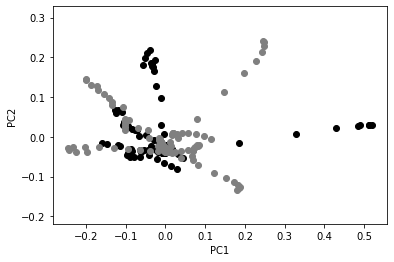

In [10]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 例: XというNumPy配列にデータが格納されているとします
# X.shape == (112, 11*23)
X1 = flat_shap1  # 実際のデータで置き換えてください

# PCAの実行
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X1)

X2 = flat_shap2  # 実際のデータで置き換えてください

# PCAの実行
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X2)

# 結果のプロット
plt.figure()
plt.scatter(X_pca1[:, 0], X_pca1[:, 1], color="black")
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], color="gray")
#plt.xlabel(f'PC1 ({pca1.explained_variance_ratio_[0]*100:.2f}% variance)')
#plt.ylabel(f'PC2 ({pca1.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
#plt.title('2次元PCAプロット')
plt.axis('equal')
plt.show()


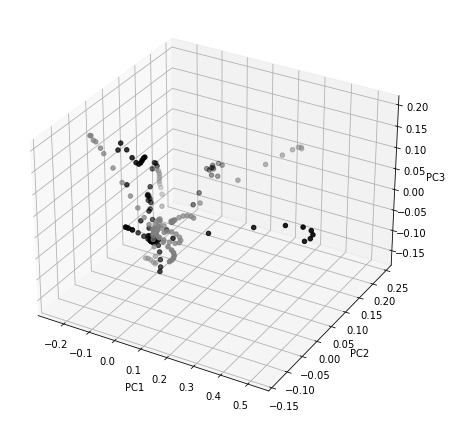

In [15]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 例: XというNumPy配列にデータが格納されているとします
# X.shape == (112, 11*23)
# X = np.random.rand(112, 11*23)  # 実際のデータで置き換えてください

X1 = flat_shap1  # 実際のデータで置き換えてください

# PCAの実行
pca1 = PCA(n_components=3)
X_pca1 = pca1.fit_transform(X1)

X2 = flat_shap2  # 実際のデータで置き換えてください

# PCAの実行
pca2 = PCA(n_components=3)
X_pca2 = pca2.fit_transform(X2)

# 3Dプロットの準備
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 散布図
ax.scatter(
    X_pca1[:, 0], X_pca1[:, 1], X_pca1[:, 2],
    s=20,  # マーカーサイズ
    color="black",
    depthshade=True
)

# 散布図
ax.scatter(
    X_pca2[:, 0], X_pca2[:, 1], X_pca2[:, 2],
    s=20,  # マーカーサイズ
    color="gray",
    depthshade=True
)

# 軸ラベルに寄与率を表示
ax.set_xlabel(f'PC1')
ax.set_ylabel(f'PC2')
ax.set_zlabel(f'PC3')
#ax.set_title('3次元PCAプロット')

plt.tight_layout()
plt.show()


c:\Users\user\.conda\envs\deepshap\lib\site-packages\matplotlib\collections.py:922: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


AttributeError: module 'matplotlib.pyplot' has no attribute 'zlabel'

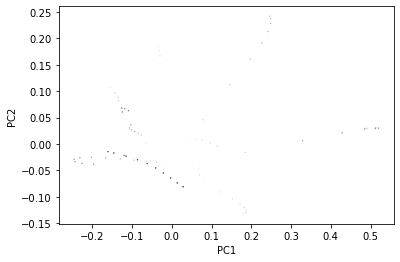

In [13]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 例: XというNumPy配列にデータが格納されているとします
# X.shape == (112, 11*23)
X1 = flat_shap1  # 実際のデータで置き換えてください

# PCAの実行
pca1 = PCA(n_components=3)
X_pca1 = pca1.fit_transform(X1)

X2 = flat_shap2  # 実際のデータで置き換えてください

# PCAの実行
pca2 = PCA(n_components=3)
X_pca2 = pca2.fit_transform(X2)

# 結果のプロット
plt.figure()
plt.scatter(X_pca1[:, 0], X_pca1[:, 1], X_pca1[:, 2], color="black")
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], X_pca2[:, 2], color="gray")
#plt.xlabel(f'PC1 ({pca1.explained_variance_ratio_[0]*100:.2f}% variance)')
#plt.ylabel(f'PC2 ({pca1.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
plt.zlabel(f'PC3')
#plt.title('2次元PCAプロット')
plt.axis('equal')
plt.show()

PC1 explained variance ratio: 0.19876596088636733
PC2 explained variance ratio: 0.18069186439582263


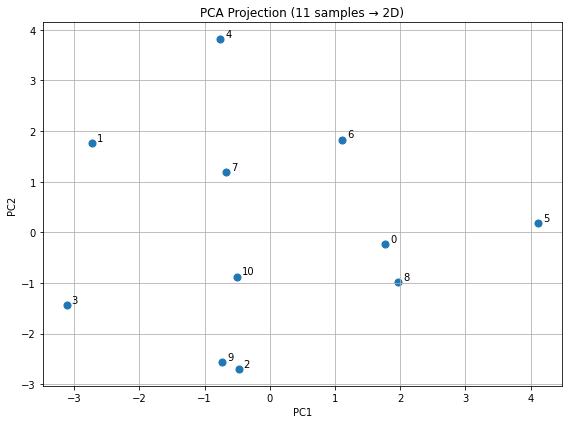

In [4]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- データ準備 ---
# 例としてランダムデータを生成。実際はご自身の (11,23) 配列をここに代入してください。
# 11 サンプル × 23 特徴量
X = np.random.randn(11, 23)

# --- PCA ---
pca = PCA(n_components=2)       # 主成分数＝2
X_pca = pca.fit_transform(X)    # shape=(11,2) に射影

# 各主成分の寄与率を表示
print("PC1 explained variance ratio:", pca.explained_variance_ratio_[0])
print("PC2 explained variance ratio:", pca.explained_variance_ratio_[1])

# --- プロット ---
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=50)

# サンプル番号をプロット上にラベル付け（必要なければ削除可）
for i in range(X.shape[0]):
    plt.annotate(str(i), (X_pca[i, 0], X_pca[i, 1]),
                 textcoords="offset points", xytext=(5, 2), ha='left')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (11 samples → 2D)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
s1 = np.mean(np.abs(shap_vals1), axis=0).reshape([look_frame+1, shap_vals1.shape[2]])
print(s1.shape)

s2 = np.mean(np.abs(shap_vals2), axis=0).reshape([look_frame+1, shap_vals2.shape[2]])
print(s2.shape)